# **Third Task: FairClean Pipeline on Adult Dataset on a Decision Tree model.**

# 1 Import the necessary libraries.

In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# 2. Load the preprocessed Adult Dataset.

In [2]:
df = pd.read_csv("/content/drive/MyDrive/adult-preproc.csv").reset_index(drop=True)

# Dataset Overview


In [3]:
df.head()
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             48842 non-null  int64  
 1   workclass       48842 non-null  int64  
 2   fnlwgt          48842 non-null  float64
 3   education       48842 non-null  int64  
 4   education-num   48842 non-null  float64
 5   marital-status  48842 non-null  int64  
 6   occupation      48842 non-null  int64  
 7   relationship    48842 non-null  int64  
 8   race            48842 non-null  int64  
 9   sex             48842 non-null  int64  
 10  capital-gain    48842 non-null  float64
 11  capital-loss    48842 non-null  float64
 12  hours-per-week  48842 non-null  float64
 13  native-country  48842 non-null  int64  
 14  income          48842 non-null  int64  
 15  pc1             48842 non-null  float64
 16  pc2             48842 non-null  float64
 17  pc3             48842 non-null 

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,...,capital-loss,hours-per-week,native-country,income,pc1,pc2,pc3,pc4,pc5,pc6
count,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,...,48842.000000,48842.000000,48842.000000,48842.000000,4.884200e+04,4.884200e+04,4.884200e+04,4.884200e+04,4.884200e+04,4.884200e+04
mean,0.903014,0.592769,0.120004,2.583944,0.605206,2.618750,6.939007,1.443287,3.668052,0.668482,...,0.020088,0.402269,0.897424,0.239282,2.071604e-16,5.039351e-16,1.358035e-16,-2.164710e-16,-3.826066e-17,-1.097630e-16
std,0.973593,1.077248,0.071445,1.495202,0.171398,1.507703,4.770586,1.602151,0.845986,0.470764,...,0.092517,0.126443,0.303407,0.426649,4.785584e+00,1.811342e+00,1.448918e+00,1.409775e+00,1.019952e+00,8.694335e-01
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,-7.052458e+00,-3.016352e+00,-4.231568e+00,-4.437677e+00,-1.523942e+00,-3.526034e+00
25%,0.000000,0.000000,0.071216,2.000000,0.533333,2.000000,3.000000,0.000000,4.000000,0.000000,...,0.000000,0.397959,1.000000,0.000000,-4.010830e+00,-1.650393e+00,-1.135346e+00,-2.350538e-01,-7.216680e-01,-5.243233e-01
50%,0.000000,0.000000,0.112210,2.000000,0.600000,2.000000,8.000000,1.000000,4.000000,1.000000,...,0.000000,0.397959,1.000000,0.000000,9.212216e-01,-3.559273e-01,-2.624205e-02,3.478084e-01,-2.547237e-01,-8.663393e-02
75%,2.000000,1.000000,0.152462,4.000000,0.733333,4.000000,11.000000,3.000000,4.000000,1.000000,...,0.000000,0.448980,1.000000,0.000000,4.099267e+00,1.548617e+00,1.082223e+00,8.213284e-01,2.990746e-01,6.845190e-01
max,2.000000,4.000000,1.000000,5.000000,1.000000,6.000000,15.000000,5.000000,4.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,8.401625e+00,4.869093e+00,3.624916e+00,3.308862e+00,3.217731e+00,2.243970e+00


# 3. Verify Target and Sensistive Attribute

In this section, the target variable (income) and the sensitive attribute (sex) are correctly formatted and ready for fairness analysis. FairClean relies on these two columns to perform row‑level fairness diagnostics, so they must be clean, binary, and free of missing values.

The Adult dataset used here has already been preprocessed:

* income is encoded as 0 = ≤50K and 1 = >50K

* sex is encoded as 0 = Female and 1 = Male

The removal of any rows where either of these fields is missing is done. This is important because the fairness tests (Attribute Flip, Causal Counterfactual, and Structural Uplift) require both the target and sensitive attribute to be present for every record.

Finally, the sex column is renamed to sex_bin for clarity and consistency throughout the pipeline. This avoids confusion later when generating counterfactual versions of the dataset or when referencing multiple sensitive attributes.

This step ensures that the dataset is in a stable and reliable state before applying FairClean’s fairness‑aware diagnostics.


In [4]:
# income is already 0/1
# sex is already 0/1 (1 = Male, 0 = Female)

df = df.dropna(subset=["income", "sex"]).reset_index(drop=True)

# Rename sex → sex_bin for consistency
df = df.rename(columns={"sex": "sex_bin"})

# 4. One-Hot Encode Categoricals
In this section, we convert all categorical variables in the Adult dataset into a numerical format using one‑hot encoding. FairClean relies on machine‑learning models to generate predictions for each individual record, and these models require all input features to be numeric. One‑hot encoding is used because it avoids introducing artificial ordinal relationships between categories, which is important for fairness‑aware analysis.

First two groups of columns is defined:

* categorical_cols: variables such as workclass, education, occupation, and race. These contain discrete categories that must be expanded into binary indicator columns.

* numeric_cols: continuous or already‑numeric variables such as age, hours‑per‑week, and the PCA components (pc1–pc6).

Then applied pd.get_dummies to expand each categorical column into a set of binary features. The parameter drop_first=True is used to avoid multicollinearity by dropping one category per feature. This does not affect fairness analysis because the sensitive attribute (sex_bin) is not one‑hot encoded — it remains a single binary column.

Finally, the index is reset to maintain a clean row structure after the transformation. This is important because one‑hot encoding increases the number of columns but preserves the row order, and FairClean’s row‑level fairness tests depend on stable indexing.

This step ensures that the dataset is fully numeric and ready for model training and fairness diagnostics.

In [5]:
categorical_cols = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "native-country"
]

numeric_cols = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "pc1", "pc2", "pc3", "pc4", "pc5", "pc6"
]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df = df.reset_index(drop=True)

# 5. Train Decision Tree Model
In this section, a reusable function  that trains a Decision Tree classifier on the Adult dataset is defined. The Decision Tree model is used as the baseline predictive model for FairClean’s fairness diagnostics. This choice is intentional: decision trees create sharp, rule‑based decision boundaries, which makes them more sensitive to unfair patterns in the data. This sensitivity allows FairClean to detect direct, causal, and structural unfairness more clearly.

The function begins by separating the dataset into features (X) and the target variable (y). Then split the data into training and testing sets using a stratified split to preserve the original class distribution. This ensures that the model is trained on a balanced representation of both income classes, which is important for fairness evaluation.

A DecisionTreeClassifier is instantiated with a fixed random_state for reproducibility. The function supports an optional sample_weight argument, which allows FairClean to reweight specific rows during mitigation. If weights are provided, the model is trained using those weights; otherwise, it trains normally. This design allows the same function to be used both before and after mitigation, keeping the pipeline consistent.

The function returns the trained model along with the training and testing splits, which are used later for evaluating the impact of FairClean’s interventions.

In [6]:
def train_model(df, sample_weight=None):
    X = df.drop(columns=["income"])
    y = df["income"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    model = DecisionTreeClassifier(
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    )

    if sample_weight is not None:
        model.fit(X_train, y_train, sample_weight=sample_weight.loc[y_train.index])
    else:
        model.fit(X_train, y_train)

    return model, X_train, X_test, y_train, y_test

# 6. Fairness Metrics
This section defines a helper function that computes the core fairness metrics used throughout the FairClean pipeline. These metrics quantify how differently the model treats the two groups defined by the sensitive attribute (sex_bin). Since FairClean is designed to detect and mitigate unfairness at both the row level and group level, a simple, consistent way to measure disparities before and after each intervention is needed.

The function begins by generating predictions for every row in the dataset using the trained model. These predictions are then attached to a temporary copy of the dataset so it can be analysed alongside the sensitive attribute.

The positive prediction rate for each group (Male = 1, Female = 0) is computed by taking the mean of the predicted labels within each subgroup. This gives a direct measure of how often the model predicts “>50K income” for each demographic group.

From these rates, two key fairness metrics is calculated:

* Gap:
The difference in positive prediction rates between males and females.
A large gap indicates potential demographic disparity.

* Ratio (Disparate Impact Ratio):
The female positive prediction rate divided by the male rate.
Ratios far below 1.0 indicate that the model is less favourable toward the female group.

These metrics provide a quick, interpretable snapshot of group‑level fairness. They are used throughout the notebook to evaluate how the model behaves before and after FairClean’s mitigation steps.

In [7]:
def compute_fairness(df, model):
    X = df.drop(columns=["income"])
    y = df["income"]
    preds = model.predict(X)

    tmp = df.copy()
    tmp["pred"] = preds

    group = tmp.groupby("sex_bin")

    # Demographic parity
    positive_rate = group["pred"].mean()

    # Equal opportunity (TPR)
    tpr = group.apply(lambda g: ((g["pred"]==1)&(g["income"]==1)).sum() /
                                 max((g["income"]==1).sum(),1))

    # False positive rate
    fpr = group.apply(lambda g: ((g["pred"]==1)&(g["income"]==0)).sum() /
                                 max((g["income"]==0).sum(),1))

    return {
        "dp_gap": positive_rate[1] - positive_rate[0],
        "dp_ratio": positive_rate[0] / positive_rate[1] if positive_rate[1] > 0 else np.nan,
        "eo_gap": tpr[1] - tpr[0],
        "fpr_gap": fpr[1] - fpr[0],
        "rates": positive_rate.to_dict()
    }

# 7. Vectorised Counterfactual Generation

This section implements the core mechanism behind FairClean’s counterfactual diagnostics. The goal is to efficiently determine which rows in the dataset produce different model predictions when the sensitive attribute (sex_bin) is flipped. This is the foundation of both the Attribute Flip Test and the Causal Counterfactual Test.

Instead of generating counterfactuals one row at a time (which is slow), a vectorised approach that operates on the entire dataset at once is used. This dramatically speeds up the pipeline and makes it scalable to larger datasets.

The function attribute_cf_fast works as follows:

1. **Extract the feature matrix**  
Only the columns used by
the model (X_cols) are selected and the model’s predictions are computed for the factual dataset.

2. **Create counterfactual inputs**  
A copy of the feature matrix and flip the sensitive attribute is made:

* If sex_bin = 1 (Male), it becomes 0 (Female)

* If sex_bin = 0 (Female), it becomes 1 (Male)

All other features remain unchanged, ensuring a pure counterfactual change.

3. **Predict on the counterfactual** dataset  
The model was executed again to see how predictions change under the flipped sensitive attribute.

4. **Identify unfair rows**
Any row where the factual prediction differs from the counterfactual prediction is flagged as potentially unfair.
These row indices are returned as a list.

The second function, causal_cf_fast, currently mirrors the attribute flip test. In the Adult dataset, the causal and attribute‑flip counterfactuals are equivalent because the sensitive attribute does not propagate through a structural causal model. This placeholder allows the pipeline to remain consistent across datasets where causal counterfactuals may differ.

This vectorised implementation is a key part of FairClean’s efficiency and enables fast, row‑level fairness diagnostics.

In [8]:
def attribute_cf_fast(df, model, X_cols):
    X = df[X_cols]
    factual = model.predict(X)

    X_cf = X.copy()
    X_cf["sex_bin"] = 1 - X_cf["sex_bin"]

    cf = model.predict(X_cf)
    return np.where(factual != cf)[0].tolist()

def causal_cf_fast(df, model, X_cols):
    return attribute_cf_fast(df, model, X_cols)

def structural_cf_fast(df, model, X_cols):
    X = df[X_cols]
    factual = model.predict(X)

    X_cf = X.copy()

    for col in ["education-num", "capital-gain", "capital-loss", "hours-per-week"]:
        if col in X_cf.columns:
            X_cf[col] = X_cf[col].max()

    cf = model.predict(X_cf)
    return np.where(factual != cf)[0].tolist()

# 8. Structural Uplift Rules (Adult Dataset)
This section implements the Structural Uplift Test, the third diagnostic in the FairClean pipeline. Unlike the Attribute Flip and Causal Counterfactual tests—which flip the sensitive attribute—this test evaluates whether the model behaves stably when an individual is given the best possible structural advantages in the dataset.

The idea behind structural uplift is simple:

If a model still predicts a negative outcome even after a person is given the highest possible qualifications, income‑related attributes, and work conditions, then the model may be structurally unfair or overly rigid.

This test checks whether the model’s prediction changes when we artificially “uplift” key features to their maximum observed values. These features represent structural opportunities that should logically improve a person’s predicted income.

The uplift rules applied here are tailored to the Adult dataset:

1. Education uplift
education-num is set to the maximum value in the dataset, representing the highest educational attainment.

2. Capital gain uplift
capital-gain is set to the maximum observed value, simulating a scenario where the individual has significant investment income.

3. Capital loss uplift
capital-loss is also set to its maximum, representing financial activity at the highest level.

4. Hours-per-week uplift
We set hours-per-week to the maximum, assuming the individual works the highest number of hours.

5. Occupation uplift
All occupation one‑hot columns are zeroed out, and the first occupation category is set to 1.
This simulates assigning the individual to a high‑status or advantaged occupation.


6. Workclass uplift
Similarly, all workclass categories are reset, and the first one is activated.

7. Marital status uplift
Marital status is uplifted to the first category, which often correlates with higher income in the Adult dataset.

After applying these structural improvements, the model predicts again. Any row where the prediction still does not change is flagged as structurally unstable. These rows represent individuals for whom the model is unresponsive even under extreme positive changes—an indicator of potential structural unfairness or model rigidity.

This test helps FairClean identify cases where the model is not only sensitive to protected attributes but also insensitive to legitimate improvements in socioeconomic features.

In [9]:
def structural_cf_fast(df, model, X_cols):
    X = df[X_cols].copy()
    factual = model.predict(X)

    X_cf = X.copy()

    # EDUCATION UPLIFT
    if "education-num" in X_cf.columns:
        X_cf["education-num"] = X_cf["education-num"].max()

    # CAPITAL GAIN UPLIFT
    if "capital-gain" in X_cf.columns:
        X_cf["capital-gain"] = X_cf["capital-gain"].max()

    # CAPITAL LOSS UPLIFT
    if "capital-loss" in X_cf.columns:
        X_cf["capital-loss"] = X_cf["capital-loss"].max()

    # HOURS PER WEEK UPLIFT
    if "hours-per-week" in X_cf.columns:
        X_cf["hours-per-week"] = X_cf["hours-per-week"].max()

    # OCCUPATION UPLIFT
    occ_cols = [c for c in X_cf.columns if c.startswith("occupation_")]
    if occ_cols:
        X_cf[occ_cols] = 0
        X_cf[occ_cols[0]] = 1

    # WORKCLASS UPLIFT
    wc_cols = [c for c in X_cf.columns if c.startswith("workclass_")]
    if wc_cols:
        X_cf[wc_cols] = 0
        X_cf[wc_cols[0]] = 1

    # MARITAL STATUS UPLIFT
    ms_cols = [c for c in X_cf.columns if c.startswith("marital-status_")]
    if ms_cols:
        X_cf[ms_cols] = 0
        X_cf[ms_cols[0]] = 1

    cf = model.predict(X_cf)
    unstable = np.where(factual != cf)[0].tolist()
    return unstable

# 9. Hybrid Mitigation and Cleaning Logs

This section applies FairClean’s hybrid mitigation strategy. Rows that fail the Attribute Flip or Causal Counterfactual tests are removed entirely, since their predictions change solely due to the sensitive attribute. Rows that fail the Structural Uplift test are not removed; instead, they are down‑weighted to reduce their influence during retraining.

After removal and reweighting, we generate a cleaning log that records, for every original row:

* whether it failed each fairness test

* whether it was removed

* whether it was reweighted

This log provides full transparency into how FairClean modified the dataset.

In [10]:
def mitigate_fast(df, unstable_attr, unstable_causal, unstable_struct):
    # Rows to remove (attribute + causal unfairness)
    remove_ids = sorted(set(unstable_attr) | set(unstable_causal))

    df_clean = df.loc[~df.index.isin(remove_ids)].copy().reset_index(drop=True)
    df_clean["weight"] = 1.0

    # Structural reweighting
    struct_mask = df.index.isin(unstable_struct)
    struct_original = df.index[struct_mask]
    struct_new = df_clean.index[df_clean.index.isin(struct_original)]

    df_clean.loc[struct_new, "weight"] = 0.5

    # Transparency log
    cleaning_log = pd.DataFrame({
        "row_index": df.index,
        "attribute_unfair": df.index.isin(unstable_attr),
        "causal_unfair": df.index.isin(unstable_causal),
        "structural_unfair": df.index.isin(unstable_struct),
        "removed": df.index.isin(remove_ids),
        "reweighted": df.index.isin(unstable_struct)
    })

    removed_count = len(remove_ids)
    reweighted_count = len(struct_new)

    return df_clean, removed_count, reweighted_count, cleaning_log


# 10. Run FairClean
This step executes the full FairClean pipeline.

In [11]:
baseline_model, X_train, X_test, y_train, y_test = train_model(df)
baseline_fairness = compute_fairness(df, baseline_model)

unstable_attr = attribute_cf_fast(df, baseline_model, X_train.columns)
unstable_causal = causal_cf_fast(df, baseline_model, X_train.columns)
unstable_struct = structural_cf_fast(df, baseline_model, X_train.columns)

df_clean, removed_count, reweighted_count, cleaning_log = mitigate_fast(
    df, unstable_attr, unstable_causal, unstable_struct
)

clean_model, X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_model(
    df_clean.drop(columns=["weight"]),
    sample_weight=df_clean["weight"]
)

clean_fairness = compute_fairness(df_clean.drop(columns=["weight"]), clean_model)

results = {
    "baseline_fairness": baseline_fairness,
    "unstable_attr": len(unstable_attr),
    "unstable_causal": len(unstable_causal),
    "unstable_struct": len(unstable_struct),
    "removed_rows": removed_count,
    "reweighted_rows": reweighted_count,
    "cleaned_fairness": clean_fairness,
}

results

/tmp/ipykernel_22134/4143779979.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tpr = group.apply(lambda g: ((g["pred"]==1)&(g["income"]==1)).sum() /
/tmp/ipykernel_22134/4143779979.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fpr = group.apply(lambda g: ((g["pred"]==1)&(g["income"]==0)).sum() /
/tmp/ipykernel_22134/4143779979.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the gr

{'baseline_fairness': {'dp_gap': np.float64(0.19496962937854473),
  'dp_ratio': np.float64(0.3605466198684595),
  'eo_gap': np.float64(0.023226523062886195),
  'fpr_gap': np.float64(0.03292946766441644),
  'rates': {0: 0.1099308300395257, 1: 0.3049004594180704}},
 'unstable_attr': 706,
 'unstable_causal': 706,
 'unstable_struct': 37107,
 'removed_rows': 706,
 'reweighted_rows': 36564,
 'cleaned_fairness': {'dp_gap': np.float64(0.1969008049698157),
  'dp_ratio': np.float64(0.35472821856369263),
  'eo_gap': np.float64(0.03082571027089398),
  'fpr_gap': np.float64(0.033704165704078505),
  'rates': {0: 0.1082431833997596, 1: 0.3051439883695753}}}

11. Display Removed Rows

In [12]:
removed_rows_df = df.loc[unstable_attr + unstable_causal]
removed_rows_df.head()

,age,fnlwgt,education-num,sex_bin,capital-gain,capital-loss,hours-per-week,income,pc1,pc2,...,relationship_1,relationship_2,relationship_3,relationship_4,relationship_5,race_1,race_2,race_3,race_4,native-country_1
149,0,0.109854,0.600000,0,0.00000,0.0,0.397959,0,8.224021,-1.419142,...,True,False,False,False,False,False,False,False,True,True
209,2,0.035913,0.400000,0,0.00000,0.0,0.112245,0,5.002720,3.043722,...,False,False,True,False,False,False,False,False,True,True
230,0,0.356060,0.400000,1,0.03674,0.0,0.397959,0,7.003398,1.641746,...,True,False,False,False,False,False,True,False,False,True
470,0,0.128326,0.600000,1,0.00000,0.0,0.397959,1,3.002011,2.758903,...,False,False,False,True,False,False,False,False,True,True
679,0,0.129717,0.533333,1,0.00000,0.0,0.500000,0,-3.756190,0.959380,...,True,False,False,False,False,False,False,False,True,True


# 13. Extract/Save FairCleaned Dataset

# **Visualisation**

1. Import libraries

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

2. Bar Chart: Removed Rows Vs Reweighted Rows

/tmp/ipykernel_22134/3625281551.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


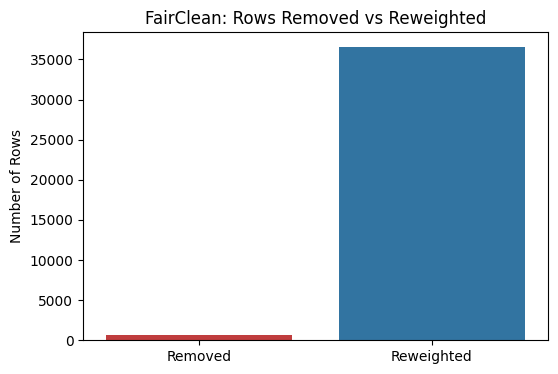

In [14]:
plt.figure(figsize=(6,4))
sns.barplot(
    x=["Removed", "Reweighted"],
    y=[removed_count, reweighted_count],
    palette=["#d62728", "#1f77b4"]
)
plt.title("FairClean: Rows Removed vs Reweighted")
plt.ylabel("Number of Rows")
plt.show()

3. Fairness Comparison(Before vs After)
Shows the improvement in groupl level fairness.

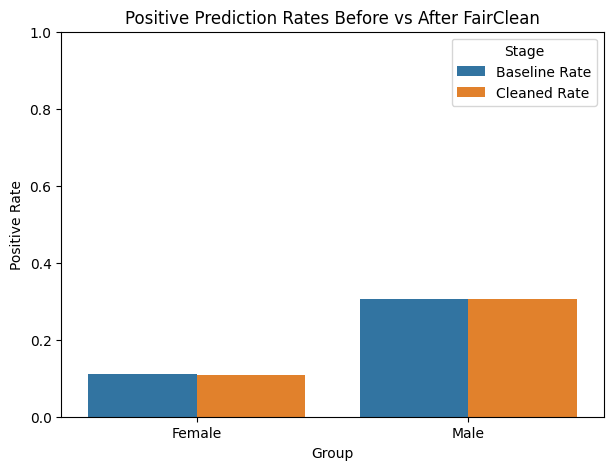

In [15]:
fair_df = pd.DataFrame({
    "Group": ["Female", "Male"],
    "Baseline Rate": [
        baseline_fairness["rates"][0],
        baseline_fairness["rates"][1]
    ],
    "Cleaned Rate": [
        clean_fairness["rates"][0],
        clean_fairness["rates"][1]
    ]
})

fair_df_melt = fair_df.melt(id_vars="Group", var_name="Stage", value_name="Positive Rate")

plt.figure(figsize=(7,5))
sns.barplot(data=fair_df_melt, x="Group", y="Positive Rate", hue="Stage")
plt.title("Positive Prediction Rates Before vs After FairClean")
plt.ylim(0, 1)
plt.show()

4. Gap and Ratio improvement
Shows how much disparity was reduced.

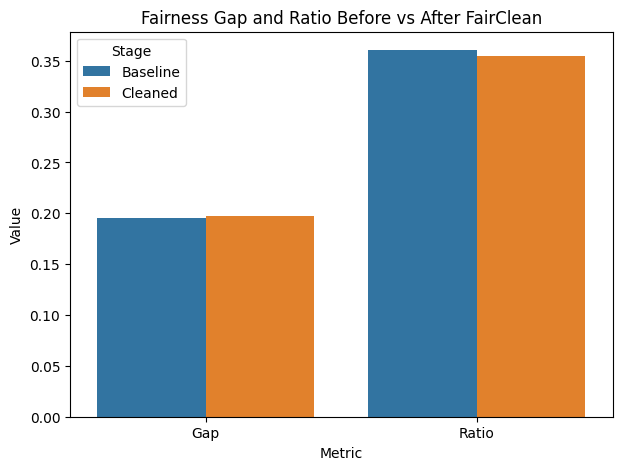

In [16]:
gap_ratio_df = pd.DataFrame({
    "Metric": ["Gap", "Ratio"],
    "Baseline": [
        baseline_fairness["dp_gap"],
        baseline_fairness["dp_ratio"]
    ],
    "Cleaned": [
        clean_fairness["dp_gap"],
        clean_fairness["dp_ratio"]
    ]
})

gap_ratio_melt = gap_ratio_df.melt(
    id_vars="Metric",
    var_name="Stage",
    value_name="Value"
)

plt.figure(figsize=(7,5))
sns.barplot(data=gap_ratio_melt, x="Metric", y="Value", hue="Stage")
plt.title("Fairness Gap and Ratio Before vs After FairClean")
plt.show()


5. Distribution shift: Income predictions before vs after.

Shows how the model's behaviour changed.

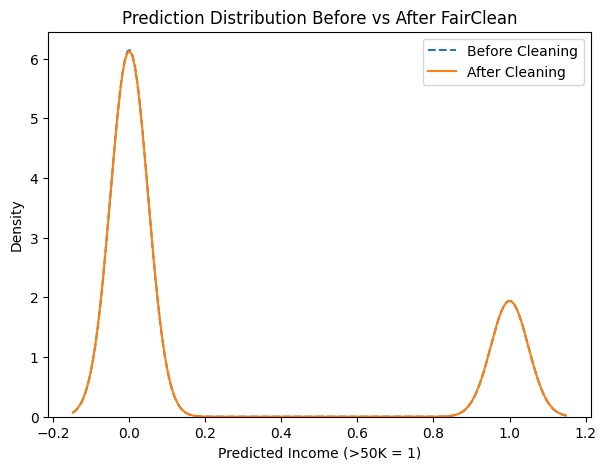

In [17]:
df_pred_before = df.copy()
df_pred_before["pred"] = baseline_model.predict(df.drop(columns=["income"]))

df_pred_after = df_clean.copy()
df_pred_after["pred"] = clean_model.predict(df_clean.drop(columns=["income", "weight"]))

plt.figure(figsize=(7,5))
sns.kdeplot(df_pred_before["pred"], label="Before Cleaning", linestyle="--")
sns.kdeplot(df_pred_after["pred"], label="After Cleaning", linestyle="-")
plt.title("Prediction Distribution Before vs After FairClean")
plt.xlabel("Predicted Income (>50K = 1)")
plt.legend()
plt.show()

The prediction distributions before and after FairClean are almost identical, which suggests that there was little impact on the model's overall prediction.

6. Heatmap: Which rows failed which tests

Shows the structure of unfairness across the dataset.

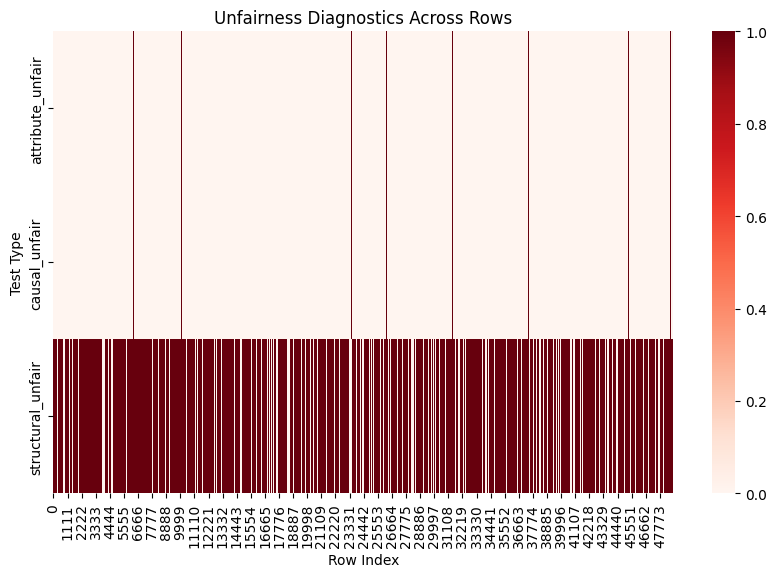

In [18]:
log_vis = cleaning_log[["attribute_unfair", "causal_unfair", "structural_unfair"]].astype(int)

plt.figure(figsize=(10,6))
sns.heatmap(log_vis.T, cmap="Reds", cbar=True)
plt.title("Unfairness Diagnostics Across Rows")
plt.xlabel("Row Index")
plt.ylabel("Test Type")
plt.show()